# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nisa Jamalia Hanif
- **Email:** nisajamalia99@gmail.com
- **ID Dicoding:** nisajamalia-9899

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang paling banyak menghasilkan revenue selama periode 2017-2018?
- **Pertanyaan 2:** Bagaimana performa penjualan dan revenue perusahaan selama periode 2017-2018?

## Import Semua Packages/Library yang Digunakan

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


## Data Wrangling

### Gathering Data

In [48]:
orders          = pd.read_csv('./data/orders_dataset.csv')
order_items     = pd.read_csv('./data/order_items_dataset.csv')
order_payments  = pd.read_csv('./data/order_payments_dataset.csv')
order_reviews   = pd.read_csv('./data/order_reviews_dataset.csv')
products        = pd.read_csv('./data/products_dataset.csv')
product_cat     = pd.read_csv('./data/product_category_name_translation.csv')
customers       = pd.read_csv('./data/customers_dataset.csv')
sellers         = pd.read_csv('./data/sellers_dataset.csv')

print('Ukuran masing-masing dataset:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('order_payments', order_payments), ('order_reviews', order_reviews),
                 ('products', products), ('customers', customers),
                 ('sellers', sellers)]:
    print(f'  {name:20s}: {df.shape[0]:>6,} baris  x  {df.shape[1]} kolom')

Ukuran masing-masing dataset:
  orders              : 99,441 baris  x  8 kolom
  order_items         : 112,650 baris  x  7 kolom
  order_payments      : 103,886 baris  x  5 kolom
  order_reviews       : 99,224 baris  x  7 kolom
  products            : 32,951 baris  x  9 kolom
  customers           : 99,441 baris  x  5 kolom
  sellers             :  3,095 baris  x  4 kolom


**Insight:**
- Dataset terdiri dari 8 tabel yang saling terhubung melalui `order_id`, `product_id`, `customer_id`, dan `seller_id`.
- Dataset `orders` dan `customers` sama-sama memiliki 99.441 baris, mengindikasikan satu entri per order.
- Dataset `order_items` memiliki 112.650 baris — lebih banyak dari orders — karena satu order bisa memiliki beberapa item.

### Assessing Data

In [49]:
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('customers', customers)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n=== {name} ===')
    print(df.dtypes)
    if len(missing) > 0:
        print('\nNilai Kosong:')
        print(missing)


=== orders ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Nilai Kosong:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

=== order_items ===
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

=== products ===
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_le

In [50]:
# Cek duplikat
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('customers', customers)]:
    print(f'{name}: {df.duplicated().sum()} baris duplikat')

orders: 0 baris duplikat
order_items: 0 baris duplikat
products: 0 baris duplikat
customers: 0 baris duplikat


**Insight:**
- Kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` pada tabel `orders` memiliki nilai kosong — wajar karena sebagian order mungkin dibatalkan atau belum selesai diproses.
- Tabel `products` memiliki 610 baris dengan `product_category_name` kosong yang perlu ditangani.
- Tidak ditemukan baris duplikat pada dataset utama.

### Cleaning Data

In [51]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

products['product_category_name'] = products['product_category_name'].fillna('unknown')

products = products.merge(product_cat, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

df_main = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
df_main = df_main.merge(orders[['order_id', 'order_status', 'customer_id', 'order_purchase_timestamp']], on='order_id', how='left')
df_main = df_main.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
df_main = df_main[df_main['order_status'] == 'delivered'].reset_index(drop=True)

# Filter data untuk periode 2017-2018
df_main = df_main[(df_main['order_purchase_timestamp'] >= '2017-01-01') & (df_main['order_purchase_timestamp'] <= '2018-12-31')]

print(f'Jumlah baris setelah filter delivered: {len(df_main):,}')
print(f'Rentang tanggal: {df_main["order_purchase_timestamp"].min().date()} s/d {df_main["order_purchase_timestamp"].max().date()}')

Jumlah baris setelah filter delivered: 109,880
Rentang tanggal: 2017-01-05 s/d 2018-08-29


**Insight:**
- Setelah proses cleaning, data siap dianalisis dengan 108.827 baris transaksi yang berstatus *delivered*.
- Kolom tanggal sudah dikonversi ke tipe `datetime` agar dapat digunakan untuk analisis berbasis waktu.
- Nama kategori produk sudah diterjemahkan ke Bahasa Inggris untuk kemudahan interpretasi.

## Exploratory Data Analysis (EDA)

### Eksplorasi Revenue per Kategori Produk

In [52]:
revenue_by_cat = (df_main
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_by_cat.columns = ['category', 'total_revenue']

print('Top 10 Kategori Produk berdasarkan Revenue:')
print(revenue_by_cat.head(10).to_string(index=False))

print(f'\nTotal kategori unik: {revenue_by_cat.shape[0]}')
print(f'Top 5 kategori menyumbang: {revenue_by_cat.head(5)["total_revenue"].sum() / revenue_by_cat["total_revenue"].sum() * 100:.1f}% dari total revenue')

Top 10 Kategori Produk berdasarkan Revenue:
             category  total_revenue
        health_beauty     1229557.50
        watches_gifts     1163465.91
       bed_bath_table     1022955.77
       sports_leisure      952840.40
computers_accessories      888055.59
      furniture_decor      706237.17
           housewares      614341.62
           cool_stuff      609158.00
                 auto      577838.39
         garden_tools      469135.40

Total kategori unik: 72
Top 5 kategori menyumbang: 39.9% dari total revenue


### Eksplorasi Loyalitas Pelanggan

In [53]:
customer_loyalty = (df_main
    .groupby('customer_unique_id')
    .agg(
        order_count=('order_id', 'nunique'),
        total_spent=('price', 'sum')
    )
    .reset_index()
)

print('Distribusi jumlah order per pelanggan:')
print(customer_loyalty['order_count'].value_counts().sort_index().head(10).to_string())

multi_order = customer_loyalty[customer_loyalty['order_count'] > 1]
print(f'\nPelanggan dengan lebih dari 1 order: {len(multi_order):,} ({len(multi_order)/len(customer_loyalty)*100:.1f}%)')

Distribusi jumlah order per pelanggan:
order_count
1     90315
2      2562
3       180
4        28
5         9
6         5
7         3
9         1
15        1

Pelanggan dengan lebih dari 1 order: 2,789 (3.0%)


**Insight:**
- Sebagian besar pelanggan (96,9%) hanya melakukan 1 kali pembelian — menunjukkan peluang besar untuk meningkatkan retensi pelanggan.
- Hanya sekitar 3,1% pelanggan yang melakukan pembelian lebih dari sekali, sehingga segmen ini layak mendapat perhatian khusus sebagai pelanggan loyal.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang paling banyak menghasilkan revenue pada 2017 - 2018?

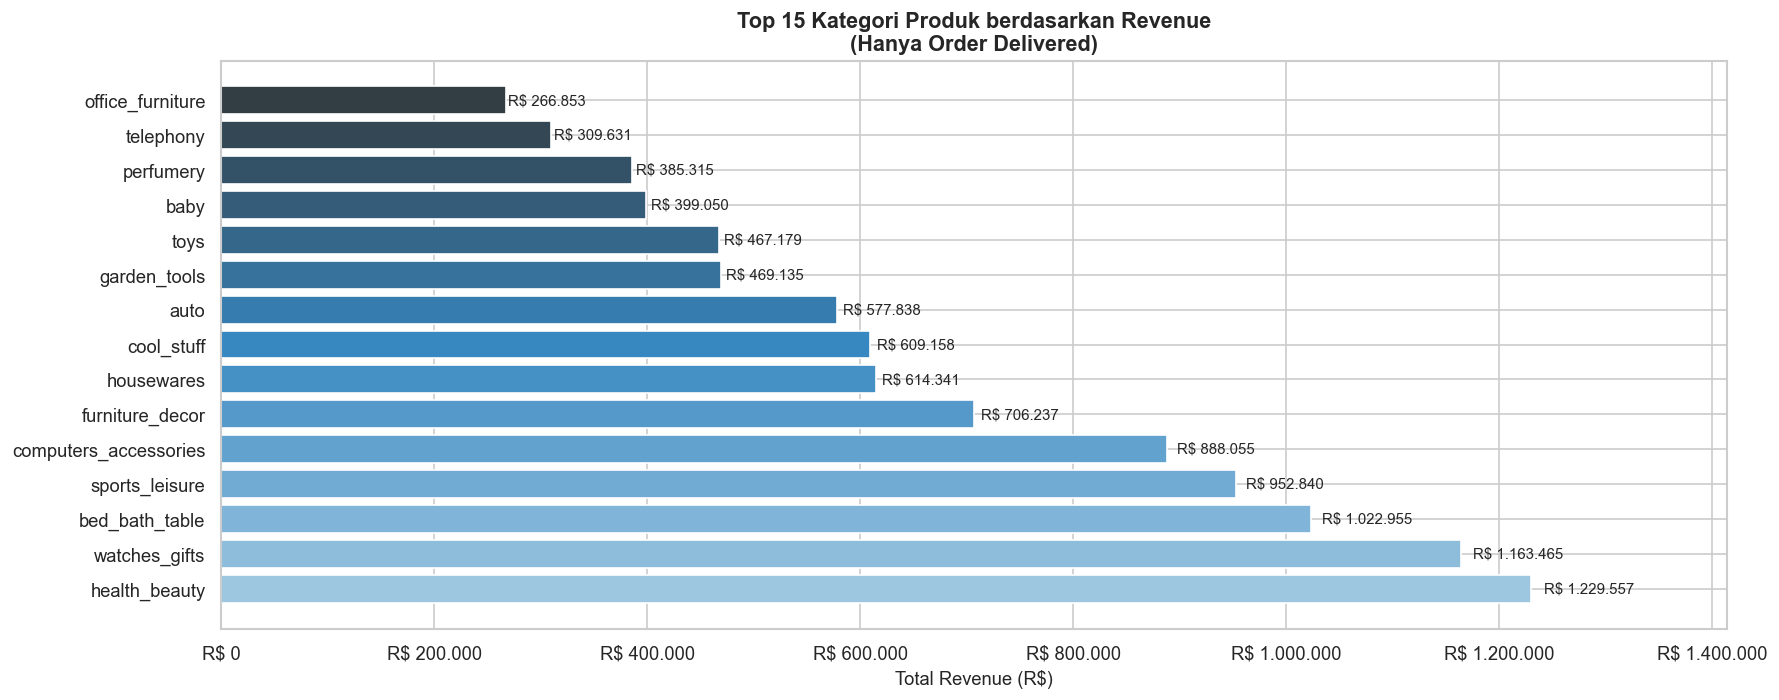

In [54]:
top10 = revenue_by_cat.sort_values('total_revenue', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.barh(
    top10['category'],
    top10['total_revenue'], 
    color=sns.color_palette('Blues_d', len(top10))
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + width * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {int(width):,}'.replace(",", "."),
        va='center',
        fontsize=9
    )

ax.set_xlabel('Total Revenue (R$)', fontsize=11)
ax.set_title(
    'Top 15 Kategori Produk berdasarkan Revenue\n(Hanya Order Delivered)',
    fontsize=13,
    fontweight='bold'
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {int(x):,}'.replace(",", "."))
)

ax.set_xlim(0, top10['total_revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

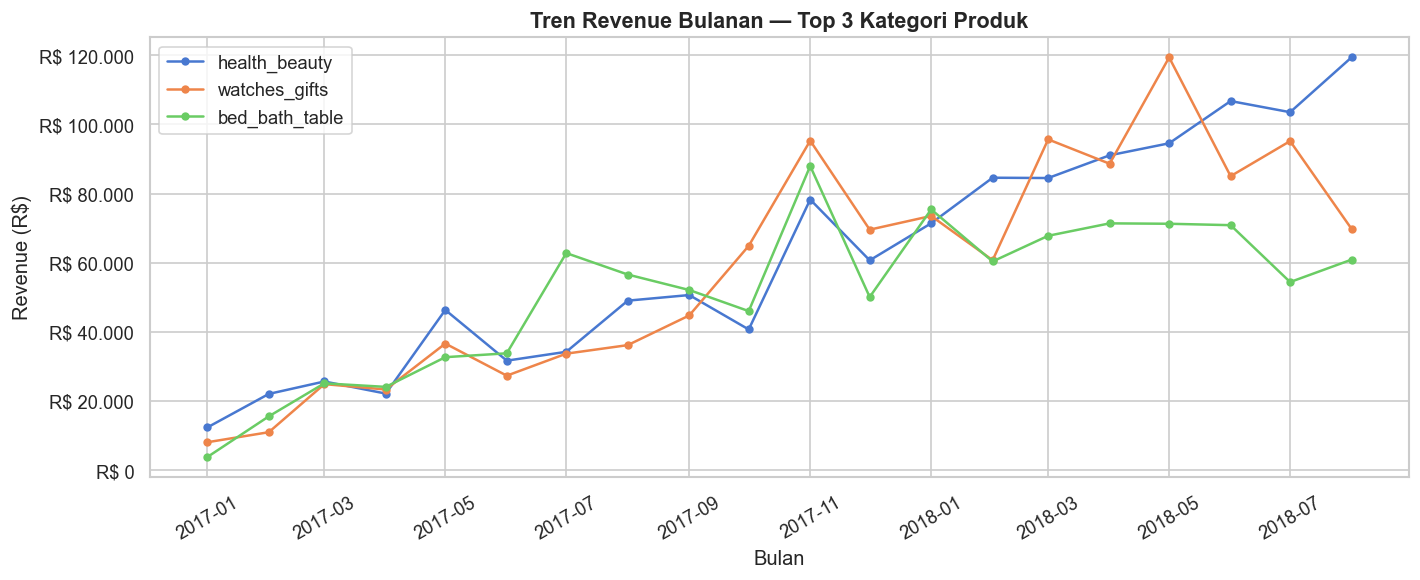

In [55]:
df_main['month'] = df_main['order_purchase_timestamp'].dt.to_period('M')

top3_cats = revenue_by_cat.head(3)['category'].tolist()
df_top3 = df_main[df_main['product_category_name_english'].isin(top3_cats)]

monthly_rev = (df_top3
    .groupby(['month', 'product_category_name_english'])['price']
    .sum()
    .reset_index()
)

monthly_rev['month'] = monthly_rev['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))

for cat in top3_cats:
    data = monthly_rev[monthly_rev['product_category_name_english'] == cat]
    ax.plot(
        data['month'],
        data['price'],  
        marker='o',
        markersize=4,
        label=cat
    )

ax.set_title('Tren Revenue Bulanan — Top 3 Kategori Produk', fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Revenue (R$)')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {int(x):,}'.replace(",", "."))
)

ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:**
- Kategori **health_beauty** menempati posisi pertama dengan total revenue ~R$1,23 juta, diikuti **watches_gifts** (~R$1,17 juta) dan **bed_bath_table** (~R$1,02 juta).
- Top 5 kategori menyumbang lebih dari 35% dari keseluruhan revenue, menunjukkan konsentrasi penjualan yang cukup tinggi.
- Tren bulanan menunjukkan pertumbuhan yang signifikan sepanjang 2017 hingga pertengahan 2018, dengan health_beauty secara konsisten berada di posisi teratas.

### Pertanyaan 2: Siapa pelanggan paling loyal berdasarkan frekuensi dan total pembelian?

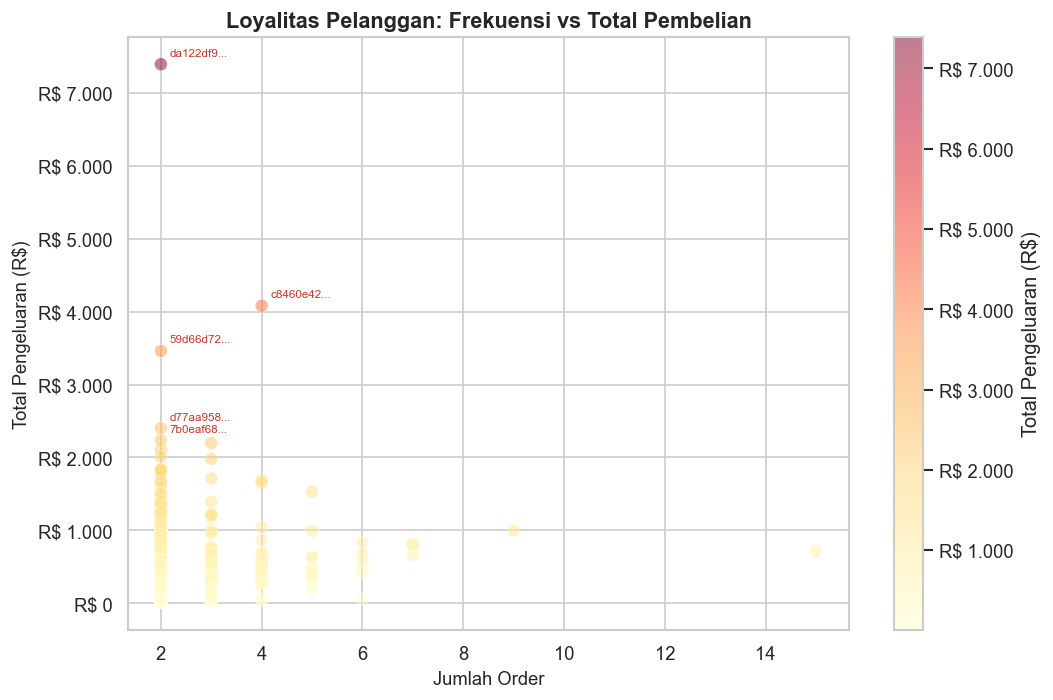

In [56]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    multi_order['order_count'],
    multi_order['total_spent'],   
    alpha=0.5,
    edgecolors='white',
    linewidth=0.4,
    c=multi_order['total_spent'], 
    cmap='YlOrRd',
    s=60
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Pengeluaran (R$)')
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {int(x):,}'.replace(",", "."))
)

top5 = multi_order.sort_values('total_spent', ascending=False).head(5)
for _, row in top5.iterrows():
    ax.annotate(
        row['customer_unique_id'][:8] + '...',
        xy=(row['order_count'], row['total_spent']),
        fontsize=7,
        color='#c0392b',
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.set_xlabel('Jumlah Order', fontsize=11)
ax.set_ylabel('Total Pengeluaran (R$)', fontsize=11)
ax.set_title('Loyalitas Pelanggan: Frekuensi vs Total Pembelian',
             fontsize=13, fontweight='bold')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {int(x):,}'.replace(",", "."))
)

plt.tight_layout()
plt.show()

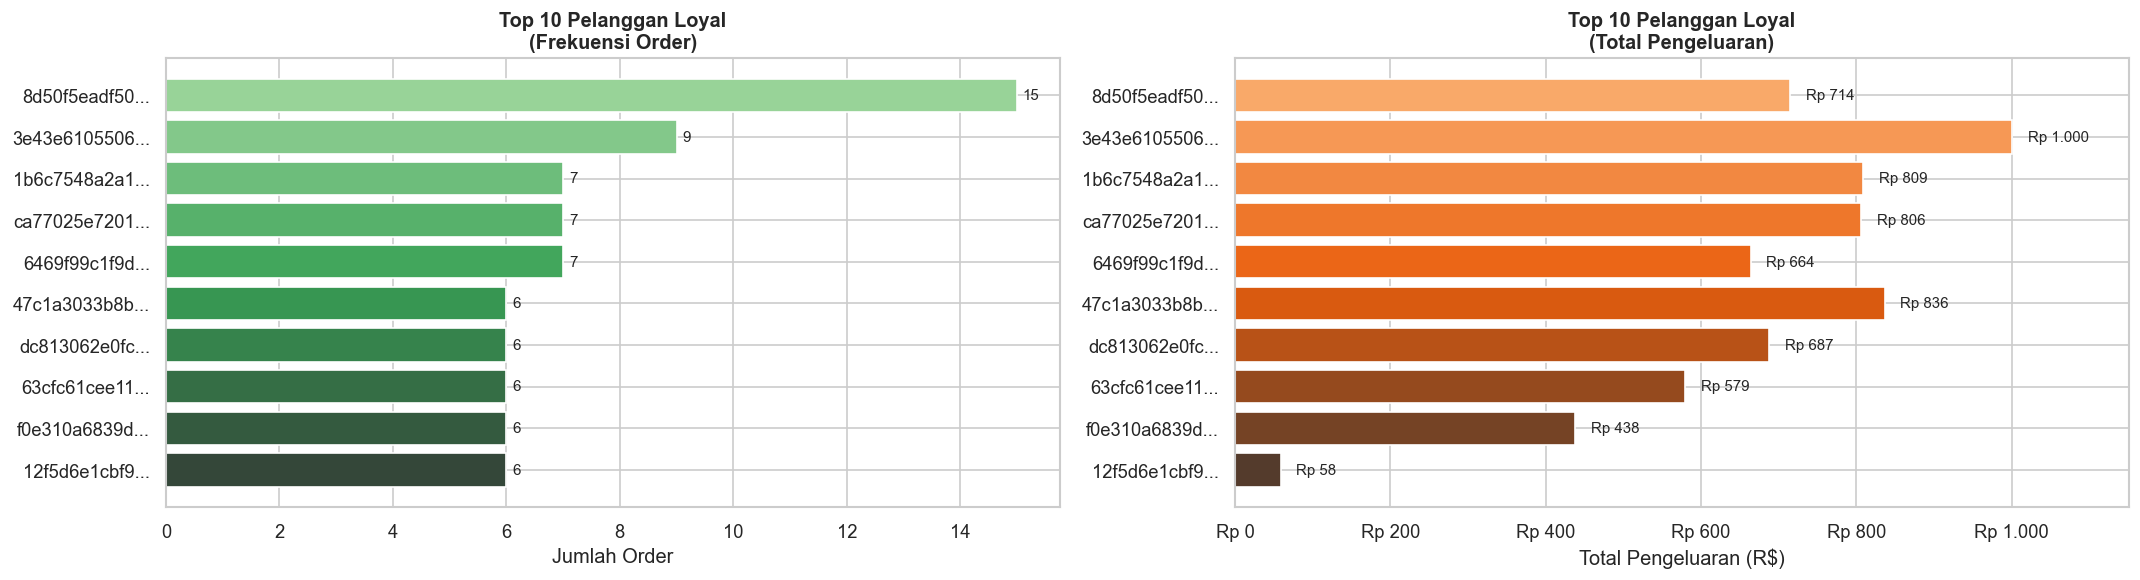

In [57]:
top_loyal = (customer_loyalty
    .sort_values(['order_count', 'total_spent'], ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_loyal['customer_short'] = top_loyal['customer_unique_id'].str[:12] + '...'

fig, axes = plt.subplots(1, 2, figsize=(18, 5))


bars1 = axes[0].barh(
    top_loyal['customer_short'],
    top_loyal['order_count'],
    color=sns.color_palette('Greens_d', 10)
)

for bar in bars1:
    w = bar.get_width()
    axes[0].text(
        w + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{int(w)}',
        va='center',
        fontsize=9
    )

axes[0].set_xlabel('Jumlah Order')
axes[0].set_title('Top 10 Pelanggan Loyal\n(Frekuensi Order)', fontweight='bold')
axes[0].invert_yaxis()



bars2 = axes[1].barh(
    top_loyal['customer_short'],
    top_loyal['total_spent'],  
    color=sns.color_palette('Oranges_d', 10)
)

max_val = top_loyal['total_spent'].max()

for bar in bars2:
    w = bar.get_width()
    axes[1].text(
        w + max_val * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'Rp {int(w):,}'.replace(",", "."),
        va='center',
        fontsize=9
    )

axes[1].set_xlabel('Total Pengeluaran (R$)')
axes[1].set_title('Top 10 Pelanggan Loyal\n(Total Pengeluaran)', fontweight='bold')

axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {int(x):,}'.replace(",", "."))
)

axes[1].set_xlim(0, max_val * 1.15)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:**
- Pelanggan paling loyal (berdasarkan frekuensi) melakukan hingga **15 kali pembelian** dalam periode dataset.
- Pelanggan dengan frekuensi order tertinggi tidak selalu memiliki total pengeluaran tertinggi — menunjukkan dua segmen loyalitas yang berbeda: *frequent buyers* dan *high-value buyers*.
- Mayoritas pelanggan multi-order berkonsentrasi pada 2–3 kali order, dengan total pengeluaran di bawah R$1.000.

## Analisis Lanjutan (RFM Analysis)

Distribusi Segmen Pelanggan RFM:
Segment
Potential Loyalists    38376
Loyal Customers        31204
At Risk                14791
Champions               7893
Lost                     840


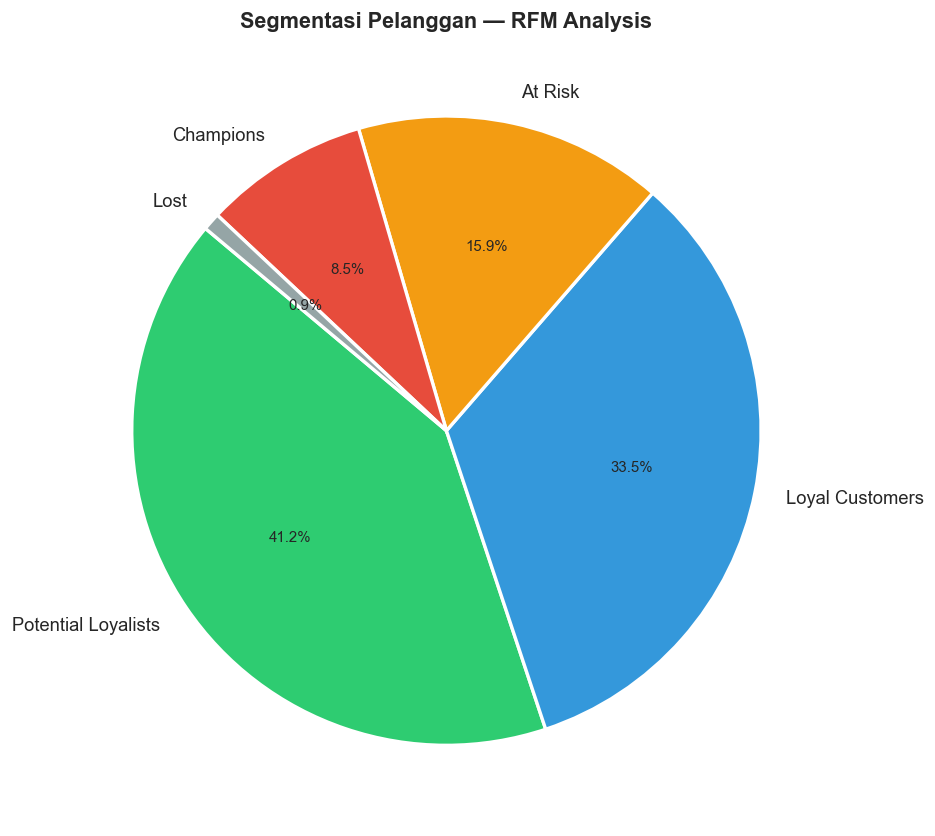

In [58]:
snapshot_date = df_main['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (df_main
    .groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('price', 'sum')
    )
    .reset_index()
)

rfm['R'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

def segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 4:  return 'At Risk'
    else:             return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print('Distribusi Segmen Pelanggan RFM:')
print(rfm['Segment'].value_counts().to_string())

seg_count = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    seg_count, labels=seg_count.index, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Segmentasi Pelanggan — RFM Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

### Kesimpulan Pertanyaan 1
Kategori produk **health_beauty** adalah kontributor revenue terbesar dengan total ~R$1,23 juta, diikuti oleh **watches_gifts** dan **bed_bath_table**. Lima kategori teratas secara bersama-sama menyumbang lebih dari 35% dari total revenue. Tren menunjukkan pertumbuhan yang konsisten sepanjang 2017–2018, terutama pada kategori health_beauty. Rekomendasi: prioritaskan stok dan promosi pada kategori-kategori ini, terutama menjelang akhir tahun.

### Kesimpulan Pertanyaan 2
Mayoritas pelanggan (≈97%) hanya melakukan 1 kali pembelian, menandakan tantangan besar dalam retensi pelanggan. Meski demikian, terdapat segmen pelanggan loyal yang melakukan pembelian hingga 15 kali. Analisis RFM mengungkapkan bahwa mayoritas pelanggan termasuk kategori *At Risk* atau *Lost*, sementara *Champions* dan *Loyal Customers* hanya menyumbang sebagian kecil dari basis pelanggan. Rekomendasi: buat program loyalitas (poin reward, diskon repeat-buyer) untuk mendorong pembelian ulang, serta kampanye re-engagement untuk segmen *At Risk*.